# CryptoQuant — Quantitative Trading Backtesting

A modular Python framework for fetching cryptocurrency market data, computing
technical indicators, implementing rule-based trading strategies, and
evaluating performance through backtesting with professional risk management.

**Workflow:**
1. Fetch historical OHLCV data from the Bitunix API
2. Compute technical indicators (SMA, EMA, RSI, Bollinger Bands, ATR)
3. Apply a rule-based trading strategy to generate buy/sell signals
4. Backtest the strategy with stop-loss, take-profit, and trailing stop
5. Visualize equity curve, drawdown, and trade signals

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src import fetch_bitunix_data, Indicators, Strategy, Backtesting

pd.options.display.float_format = '{:.2f}'.format


---
## 1. Data Acquisition

Fetch historical OHLCV data from the Bitunix public API. The function handles
pagination and rate-limiting automatically.

In [2]:
symbol = "BTCUSDT"
interval = "15"  # 15-minute candles

df = fetch_bitunix_data(symbol, interval=interval)

print(f"Fetched {len(df)} rows from {df.index[0]} to {df.index[-1]}")
display(df)


Fetched 17279 rows from 2025-12-25 18:00:00+00:00 to 2026-06-23 17:30:00+00:00


,symbol,open,high,low,close,volume
timestamp,,,,,,
2025-12-25 18:00:00+00:00,BTCUSDT,88139.08,88314.19,88139.07,88313.54,9.18
2025-12-25 18:15:00+00:00,BTCUSDT,88313.54,88313.53,88225.94,88240.66,5.92
2025-12-25 18:30:00+00:00,BTCUSDT,88240.66,88314.37,88150.01,88254.35,8.96
2025-12-25 18:45:00+00:00,BTCUSDT,88254.35,88294.75,88241.26,88241.26,4.65
2025-12-25 19:00:00+00:00,BTCUSDT,88241.26,88249.51,88159.70,88183.82,4.49
...,...,...,...,...,...,...
2026-06-23 16:30:00+00:00,BTCUSDT,62586.01,62655.00,62576.33,62622.01,17.97
2026-06-23 16:45:00+00:00,BTCUSDT,62622.01,62636.00,62491.19,62560.00,16.59
2026-06-23 17:00:00+00:00,BTCUSDT,62560.00,62558.00,62397.98,62435.96,22.58


---
## 2. Technical Indicators

The `Indicators` class computes standard technical indicators on OHLCV data.
It is designed to be easily extended with new indicators.

In [3]:
# Creating an instance of the Indicators class to compute technical indicators
indicators = Indicators(df)

---
## 3. Trading Strategy

Three rule-based strategies are available:
- **EMA Crossover + Volume** — Buy when short EMA crosses above long EMA with above-average volume
- **EMA + RSI** — Buy when price > EMA and RSI crosses up from oversold
- **Bollinger Bands + RSI** — Buy when price crosses above the lower band

We'll use the **EMA Crossover + Volume** strategy for this example.

In [4]:
df_signals = Strategy(df).ema_crossover_volume(
    short_period=21, long_period=48, volume_period=20
)

print(f"Buy signals: {(df_signals['signal'] == 1).sum()}")
print(f"Sell signals: {(df_signals['signal'] == -1).sum()}")
display(df_signals)

Buy signals: 89
Sell signals: 85


,open,high,low,close,volume,EMA_21,EMA_48,MA_VOLUME,signal
timestamp,,,,,,,,,
2025-12-25 22:45:00+00:00,87715.21,87709.82,87311.02,87650.00,44.42,87974.66,88115.69,9.49,0
2025-12-25 23:00:00+00:00,87650.00,87771.01,87486.74,87692.67,24.04,87949.03,88098.42,10.24,0
2025-12-25 23:15:00+00:00,87692.67,87695.68,87463.76,87491.00,15.02,87907.39,88073.63,10.69,0
2025-12-25 23:30:00+00:00,87491.00,87491.01,87023.73,87054.85,43.55,87829.88,88032.05,12.42,0
2025-12-25 23:45:00+00:00,87054.85,87319.32,86950.47,87225.27,34.75,87774.92,87999.12,13.93,0
...,...,...,...,...,...,...,...,...,...
2026-06-23 16:30:00+00:00,62586.01,62655.00,62576.33,62622.01,17.97,62507.80,62752.27,37.51,0
2026-06-23 16:45:00+00:00,62622.01,62636.00,62491.19,62560.00,16.59,62512.55,62744.42,37.27,0
2026-06-23 17:00:00+00:00,62560.00,62558.00,62397.98,62435.96,22.58,62505.59,62731.83,37.12,0


In [5]:
# 4. Backtesting
# Parameters: SL=3%, TP=6%, TSL=2%
backtest = Backtesting(
    df_signals, indicators, interval=interval,
    sl_pct=3, tp_pct=6, tsl_pct=2, tsl_atr=False
)

trades_df, equity_df = backtest.calculate_sl_tp_tsl()
stats = backtest.stats()

display(trades_df)


,entry_time,exit_time,entry_price,exit_price,side,exit_reason,return
0,2025-12-26 03:00:00+00:00,2025-12-26 14:45:00+00:00,89044.06,87380.44,long,tsl,-0.02
1,2025-12-26 15:00:00+00:00,2025-12-27 19:00:00+00:00,86776.12,87558.28,short,opposite,-0.01
2,2025-12-29 00:15:00+00:00,2025-12-29 09:30:00+00:00,88011.63,88232.85,long,tsl,0.00
3,2025-12-30 08:15:00+00:00,2025-12-31 15:30:00+00:00,87832.64,88045.06,long,opposite,0.00
4,2026-01-01 11:15:00+00:00,2026-01-03 07:15:00+00:00,87926.18,89415.99,long,opposite,0.02
...,...,...,...,...,...,...,...
93,2026-06-10 13:45:00+00:00,2026-06-10 21:45:00+00:00,62146.43,61356.18,long,tsl,-0.01
94,2026-06-11 01:15:00+00:00,2026-06-12 07:00:00+00:00,62176.00,62983.32,long,opposite,0.01
95,2026-06-13 01:45:00+00:00,2026-06-16 02:15:00+00:00,63837.89,65783.45,long,tsl,0.03
96,2026-06-16 13:45:00+00:00,2026-06-17 16:15:00+00:00,66052.01,66259.28,short,tsl,-0.00


In [6]:
# 5. Performance Metrics
metrics_df = pd.DataFrame([stats]).T
metrics_df.columns = ['Value']
metrics_df.index.name = 'Metric'
display(metrics_df)

,Value
Metric,
initial_capital,10000.00
final_capital,9225.91
total_return,-0.08
total_return_pct,-7.74
cagr,-0.15
sharpe_ratio,-0.30
sortino_ratio,-0.12
max_drawdown,-0.14
num_trades,98.00


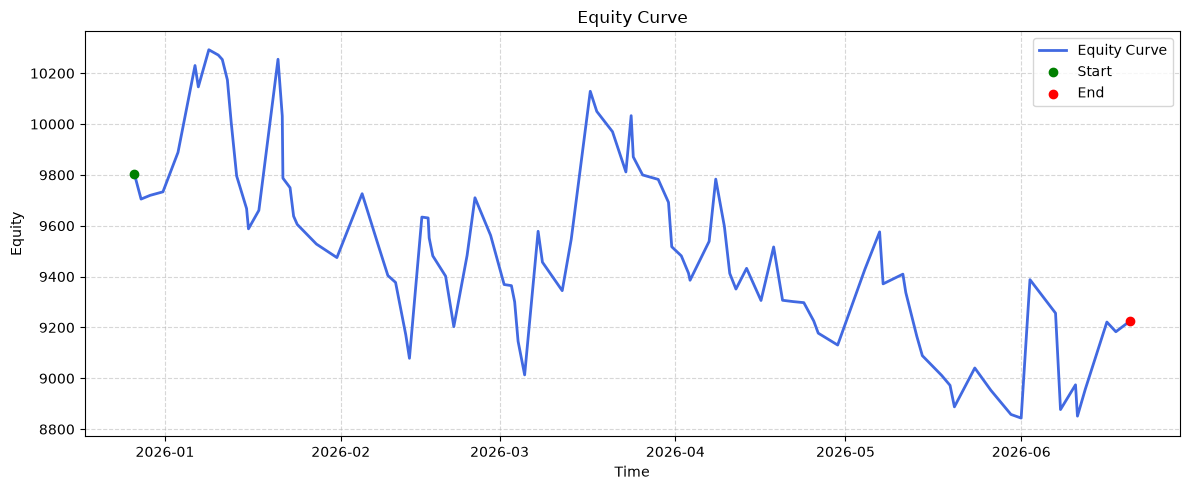

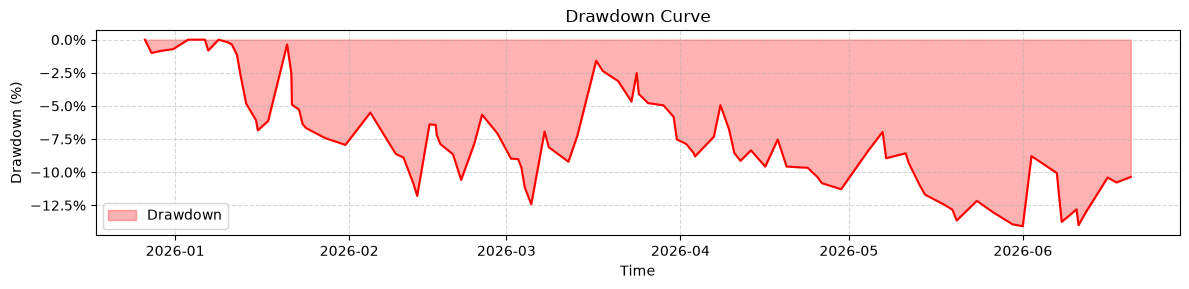

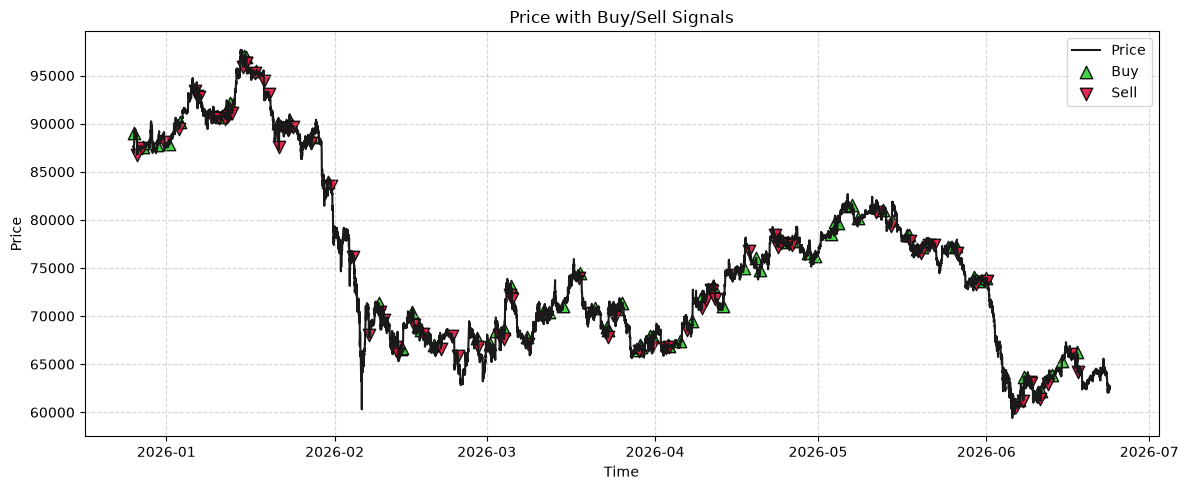

In [7]:
# 6. Visualizations

# Equity curve
plt.figure(figsize=(12, 5))
plt.plot(equity_df['time'], equity_df['equity'], label='Equity Curve', color='royalblue', linewidth=2)
plt.scatter(equity_df['time'].iloc[0], equity_df['equity'].iloc[0], color='green', label='Start', zorder=5)
plt.scatter(equity_df['time'].iloc[-1], equity_df['equity'].iloc[-1], color='red', label='End', zorder=5)
plt.title('Equity Curve')
plt.xlabel('Time')
plt.ylabel('Equity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Drawdown curve 
cumulative_max = equity_df['equity'].cummax()
drawdown = (equity_df['equity'] - cumulative_max) / cumulative_max
plt.figure(figsize=(12, 3))
plt.fill_between(equity_df['time'], drawdown, 0, color='red', alpha=0.3, label='Drawdown')
plt.plot(equity_df['time'], drawdown, color='red')
plt.title('Drawdown Curve')
plt.xlabel('Time')
plt.ylabel('Drawdown (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Signals overlaid on price
plt.figure(figsize=(12, 5))
plt.plot(df_signals.index, df_signals['close'], color="#1A1919", label='Price', linewidth=1.5)
buy = df_signals[df_signals['signal'] == 1]
sell = df_signals[df_signals['signal'] == -1]
plt.scatter(buy.index, buy['close'], marker='^', color='limegreen', label='Buy', alpha=0.9, s=80, edgecolor='k')
plt.scatter(sell.index, sell['close'], marker='v', color='crimson', label='Sell', alpha=0.9, s=80, edgecolor='k')
plt.title('Price with Buy/Sell Signals')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()